In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

{'1': 493, '0': 531}


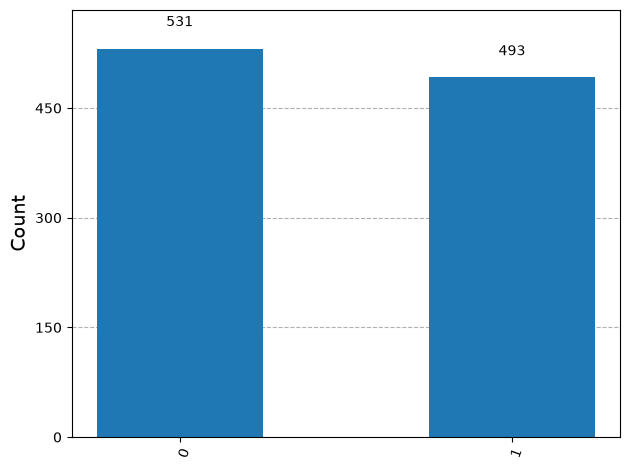

In [2]:
qc_m = QuantumCircuit(1, 1)
qc_m.h(0)
qc_m.measure(0, 0)
 
sim = AerSimulator()
compiled = transpile(qc_m, sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)
plt.show()

In [4]:
thetas = {'0': 0, 'pi/4': np.pi/4, 'pi/2': np.pi/2, '3pi/4': 3*np.pi/4, 'pi': np.pi}
for label, theta in thetas.items():
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    qc.measure(0, 0)
    compiled = transpile(qc, sim)
    result = sim.run(compiled, shots=1024).result()
    counts = result.get_counts()
    p1_sim = counts.get('1', 0) / 1024
    p1_theory = (np.sin(theta/2))**2              # TODO: write the formula sin^2(theta/2) using np.sin
    print(f'theta={label:5s} counts={counts}  P(1)_sim={p1_sim:.3f}  P(1)_theory={p1_theory:.3f}')

theta=0     counts={'0': 1024}  P(1)_sim=0.000  P(1)_theory=0.000
theta=pi/4  counts={'0': 880, '1': 144}  P(1)_sim=0.141  P(1)_theory=0.146
theta=pi/2  counts={'0': 504, '1': 520}  P(1)_sim=0.508  P(1)_theory=0.500
theta=3pi/4 counts={'0': 146, '1': 878}  P(1)_sim=0.857  P(1)_theory=0.854
theta=pi    counts={'1': 1024}  P(1)_sim=1.000  P(1)_theory=1.000


In [5]:
for shots in [100, 1024, 8192]:
    result = sim.run(compiled, shots=shots).result()
    counts = result.get_counts()
    print(f'shots={shots}:', counts)

shots=100: {'1': 100}
shots=1024: {'1': 1024}
shots=8192: {'1': 8192}
